In [ ]:
!nvidia-smi

Fri Apr  5 14:58:09 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   35C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO
import os
from IPython.display import display,Image
from IPython import display
display.clear_output()


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="JTUctzw9bONEOVa92oUi")
project = rf.workspace("biac").project("biac")
version = project.version(29)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...
Dependency ultralytics==8.0.196 is required but found version=8.1.43, to fix: `pip install ultralytics==8.0.196`


In [ ]:
model = YOLO("yolov8m-seg.pt")

model.train(data="/content/BIAC-29/data.yaml", epochs=150,imgsz=320,batch=16)  # train the model

100%|██████████| 52.4M/52.4M [00:00<00:00, 129MB/s]


Ultralytics YOLOv8.1.43 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=segment, mode=train, model=yolov8m-seg.pt, data=/content/BIAC-29/data.yaml, epochs=150, time=None, patience=100, batch=16, imgsz=320, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True,

100%|██████████| 755k/755k [00:00<00:00, 18.0MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

100%|██████████| 6.23M/6.23M [00:00<00:00, 83.5MB/s]


...

                   all        200        291      0.707      0.586      0.622      0.403      0.698      0.579      0.613      0.365



150 epochs completed in 2.335 hours.
Optimizer stripped from runs/segment/train/weights/last.pt, 54.8MB
Optimizer stripped from runs/segment/train/weights/best.pt, 54.8MB

Validating runs/segment/train/weights/best.pt...
Ultralytics YOLOv8.1.43 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8m-seg summary (fused): 245 layers, 27224121 parameters, 0 gradients, 110.0 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:04<00:00,  1.64it/s]


                   all        200        291      0.619      0.624      0.652      0.439      0.628      0.615      0.645        0.4
               Degree1        200        113       0.66      0.717      0.699      0.437      0.644      0.681      0.663       0.37
               Degree2        200        112      0.576      0.473      0.533      0.362      0.592      0.467      0.536      0.321
               Degree3        200         66      0.621      0.682      0.725      0.518      0.648      0.696      0.736       0.51
Speed: 0.1ms preprocess, 3.7ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs/segment/train


ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fdc74aaa5c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04

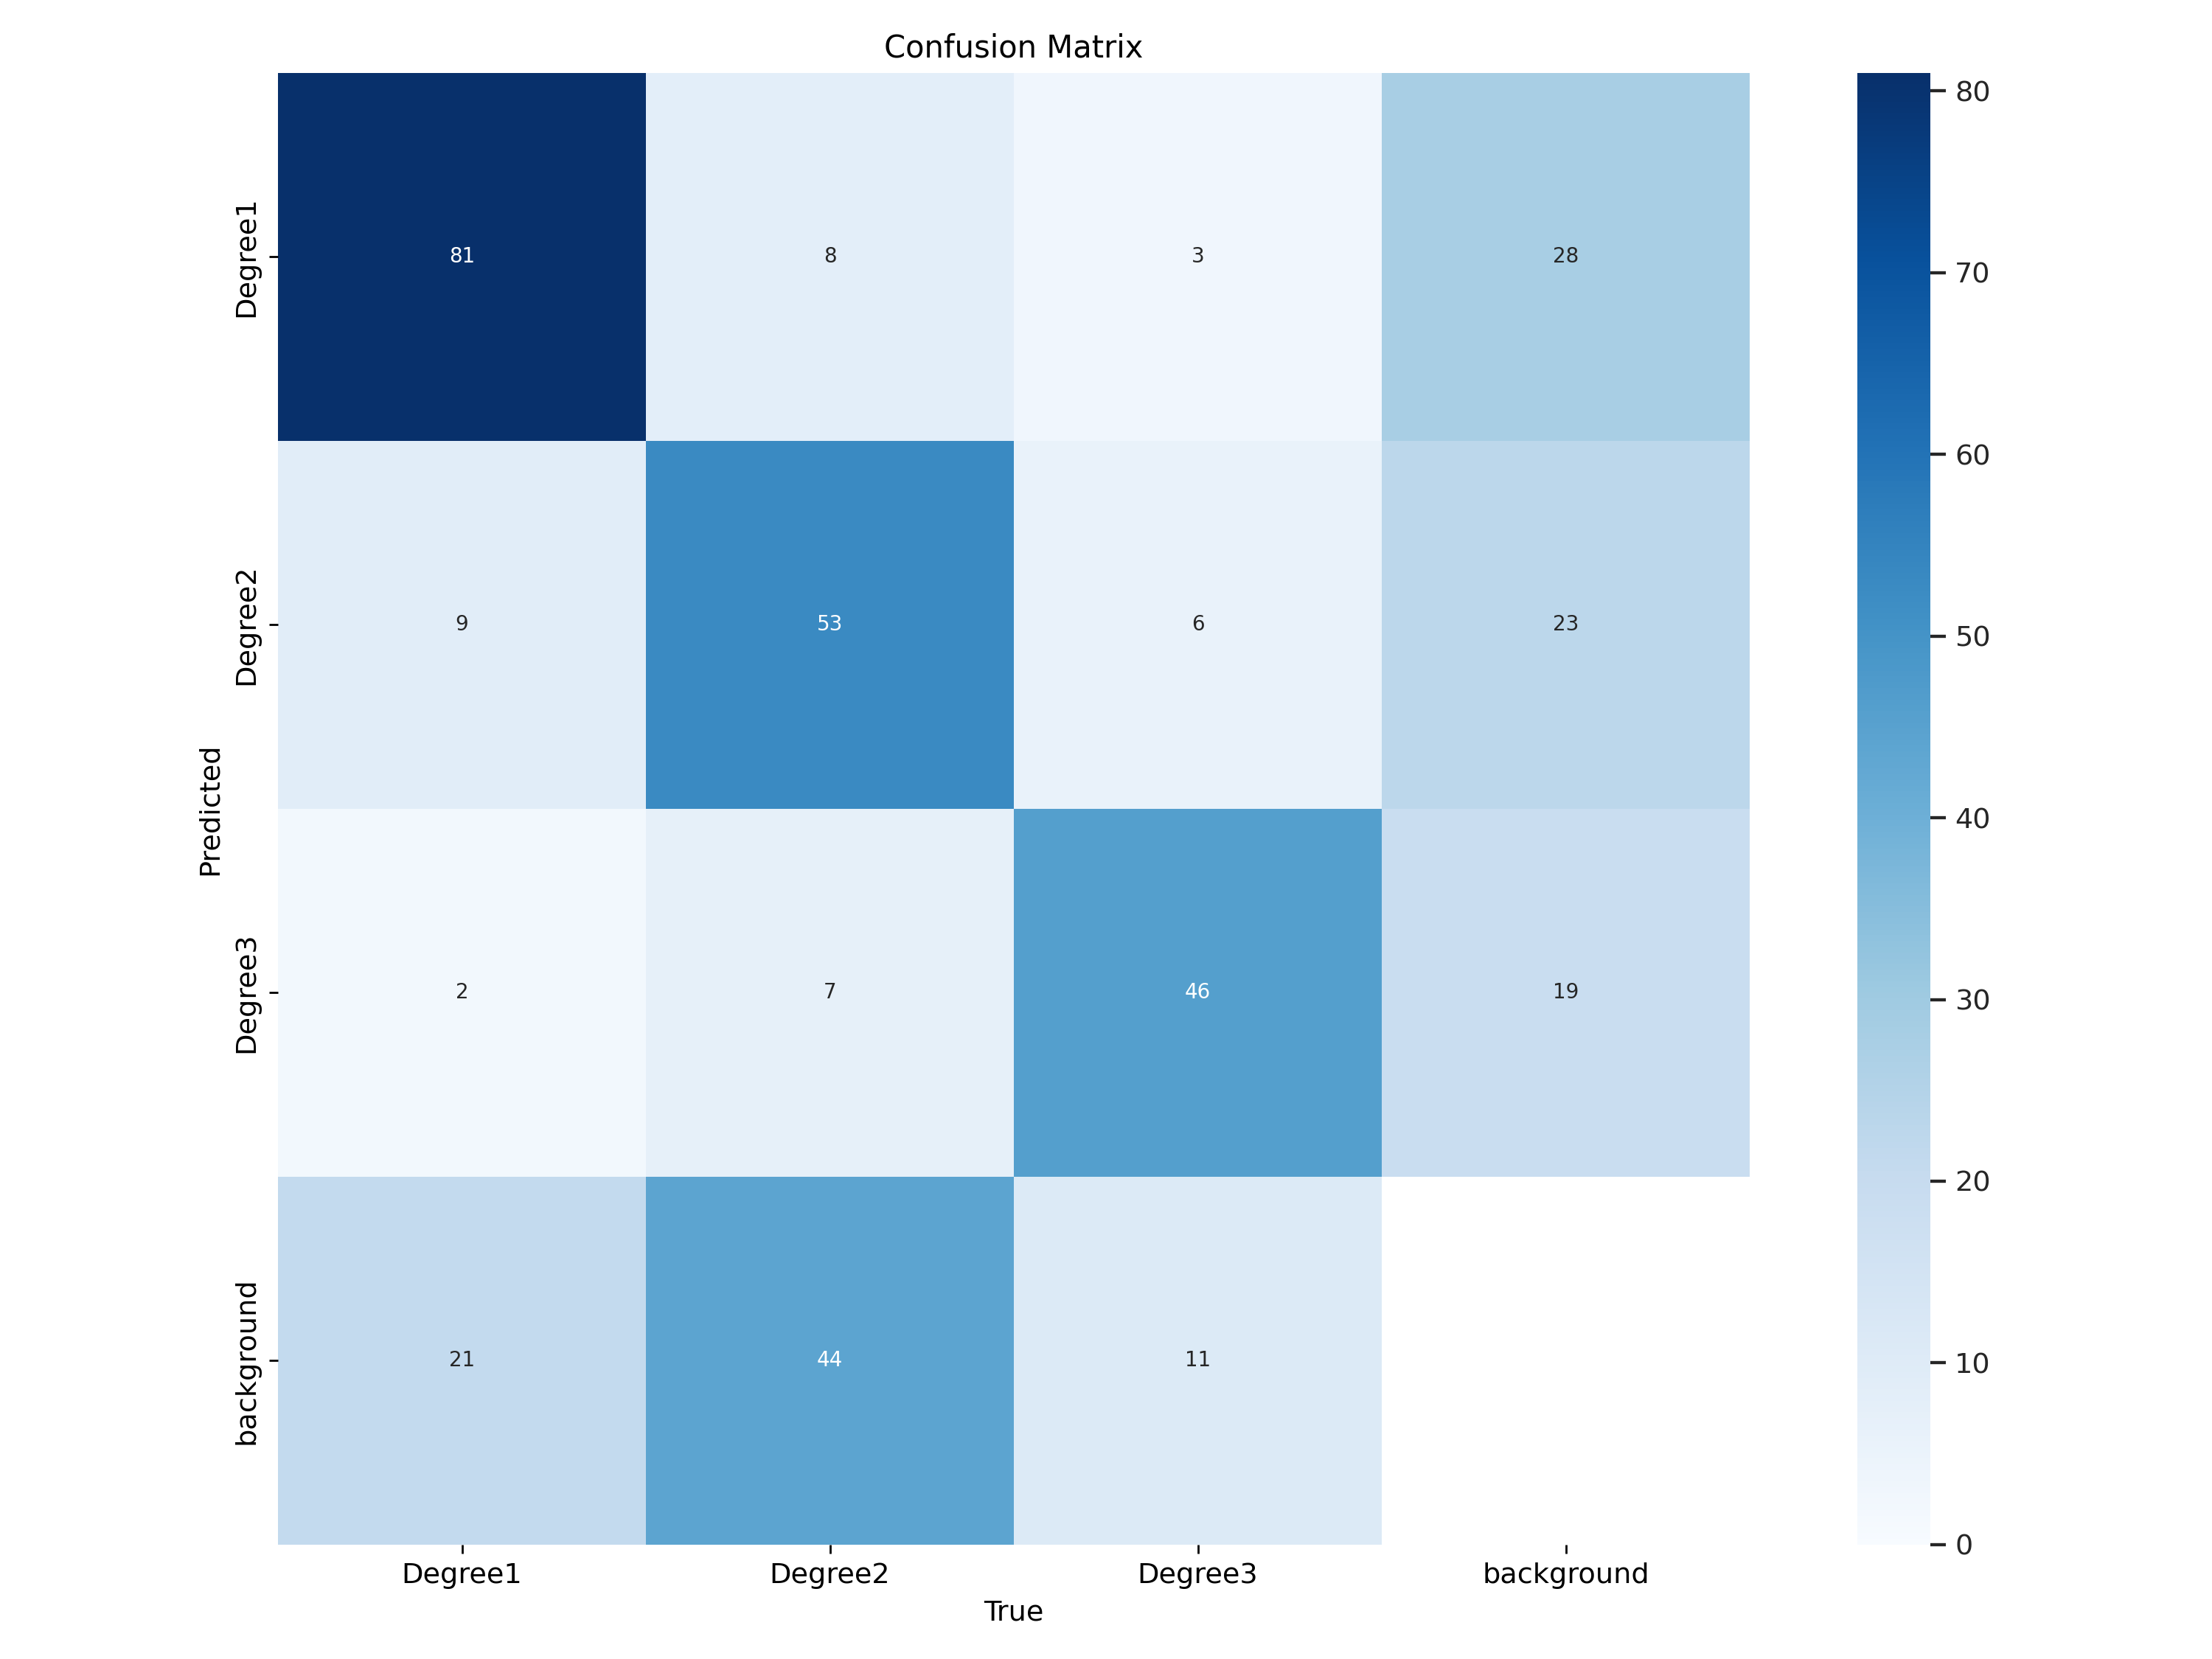

In [ ]:
Image(filename=f'/content/runs/segment/train/confusion_matrix.png',width=800)

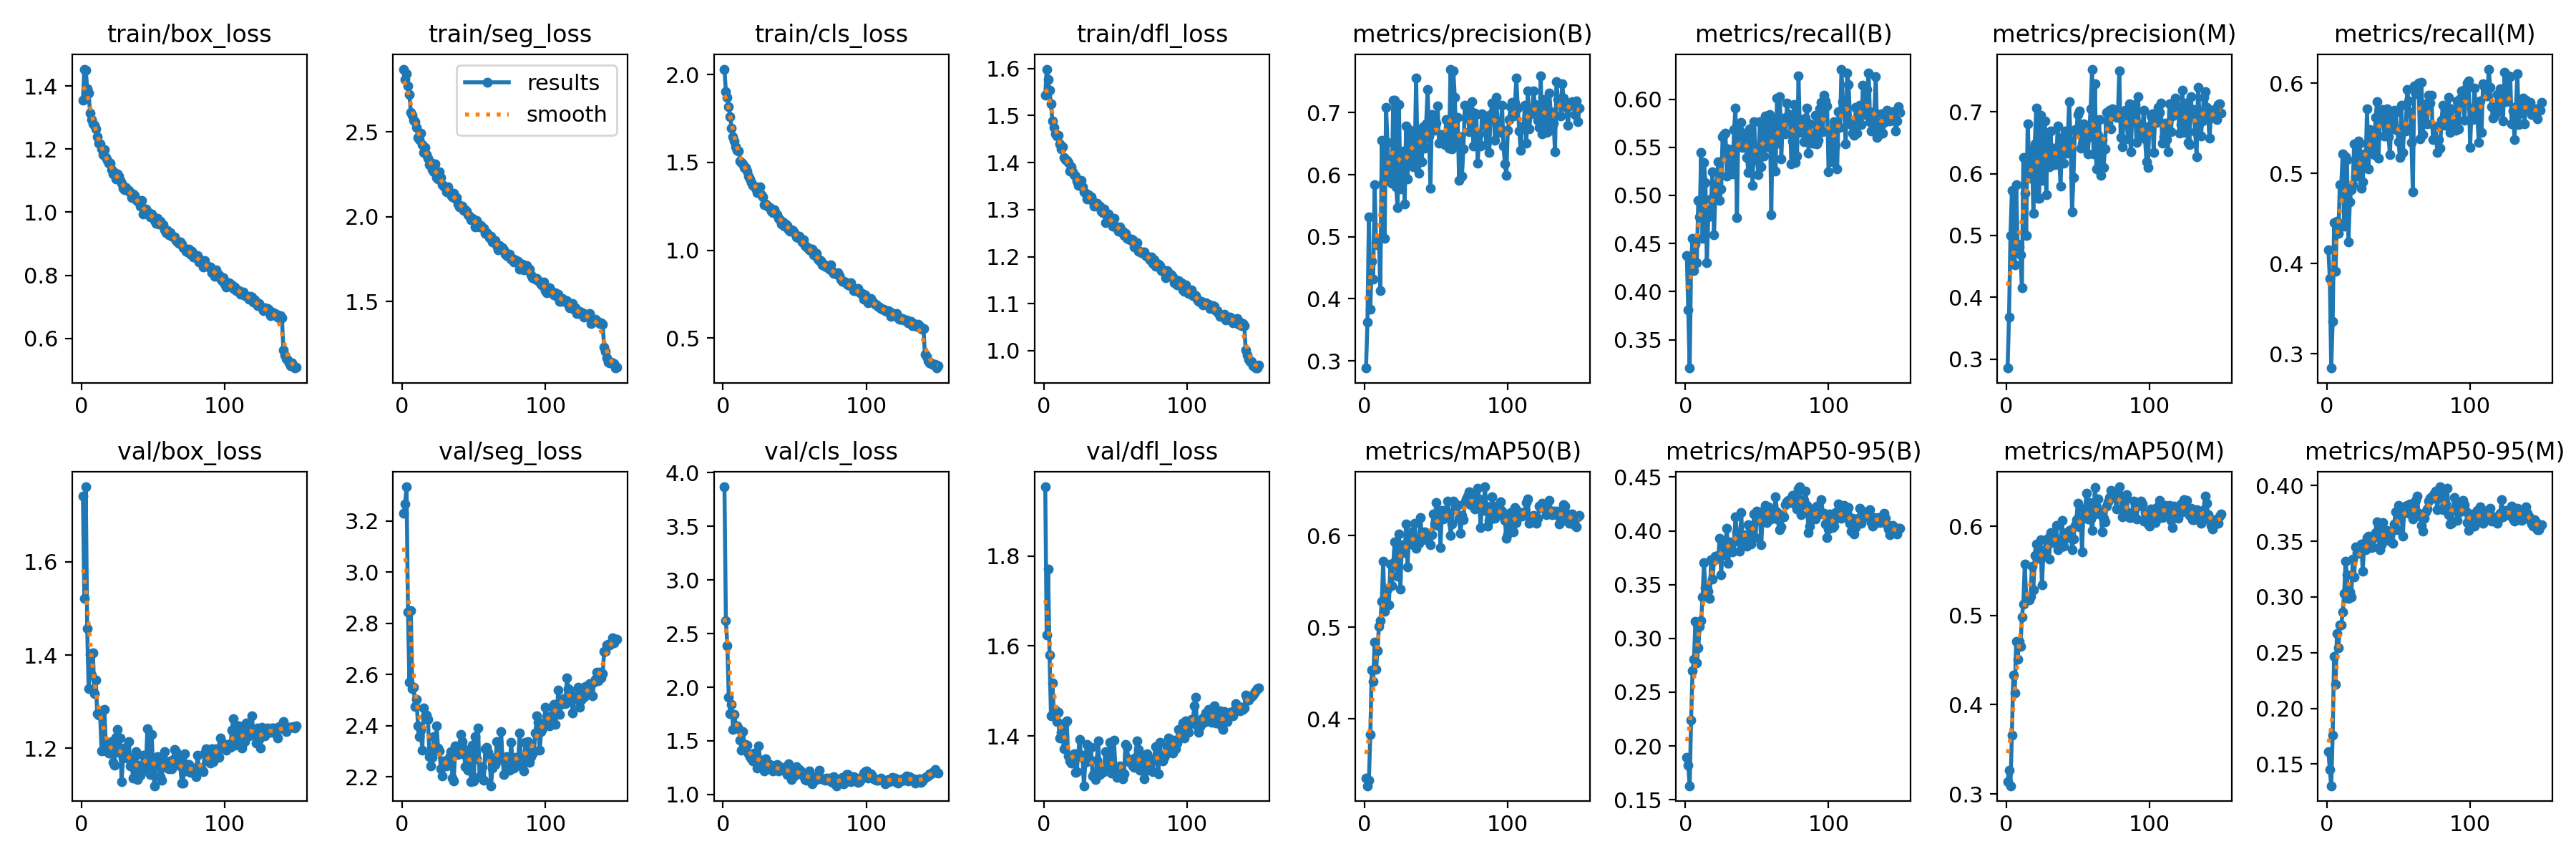

In [ ]:
Image(filename=f'/content/runs/segment/train/results.png',width=800)

In [ ]:
# Validate the model
metrics = model.val()  # no arguments needed, dataset and settings remembered
metrics.box.map    # map50-95(B)
metrics.box.map50  # map50(B)
metrics.box.map75  # map75(B)
metrics.box.maps   # a list contains map50-95(B) of each category
metrics.seg.map    # map50-95(M)
metrics.seg.map50  # map50(M)
metrics.seg.map75  # map75(M)
metrics.seg.maps   # a list contains map50-95(M) of each category

Ultralytics YOLOv8.1.43 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8m-seg summary (fused): 245 layers, 27224121 parameters, 0 gradients, 110.0 GFLOPs


val: Scanning /content/BIAC-29/valid/labels.cache... 200 images, 0 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:05<00:00,  2.20it/s]


                   all        200        291      0.624      0.627      0.654      0.438      0.627      0.614      0.645      0.398
               Degree1        200        113       0.67      0.726      0.705      0.436      0.644      0.681      0.663      0.367
               Degree2        200        112      0.581      0.473      0.533      0.362       0.59      0.464      0.536      0.319
               Degree3        200         66      0.621      0.682      0.725      0.517      0.648      0.697      0.736      0.509
Speed: 0.4ms preprocess, 10.7ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs/segment/train2


array([    0.36696,     0.31866,     0.50937])

In [ ]:
import numpy as np
def numpy(self):
    """Return a copy of the tensor as a numpy array."""
    return self if isinstance(self.data, np.ndarray) else self.__class__(self.data.numpy(), self.orig_shape)

In [ ]:
from PIL import Image
image = Image.open("/content/BIAC-29/test/images/1-135-_jpg.rf.c185d081d9220331010c5d847c553f9f.jpg")
prediction = model.predict(image)
result = prediction[0]
print(result)



0: 288x320 1 Degree1, 19.9ms
Speed: 1.0ms preprocess, 19.9ms inference, 3.9ms postprocess per image at shape (1, 3, 288, 320)
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'Degree1', 1: 'Degree2', 2: 'Degree3'}
obb: None
orig_img: array([[[ 73,  73,  73],
        [ 56,  56,  56],
        [ 52,  52,  52],
        ...,
        [ 49,  74, 114],
        [ 48,  73, 113],
        [ 47,  72, 112]],

       [[ 57,  57,  57],
        [ 58,  58,  58],
        [ 61,  61,  61],
        ...,
        [ 49,  74, 114],
        [ 48,  73, 113],
        [ 47,  72, 112]],

       [[ 52,  52,  52],
        [ 59,  59,  59],
        [ 61,  61,  61],
        ...,
        [ 47,  72, 112],
        [ 47,  72, 112],
        [ 46,  71, 111]],

       ...,

       [[149, 167, 244],
        [149, 167, 244],
        [145, 163, 240],
        ...,
        [212, 213, 211],
        [212

In [ ]:
model.save('/content/runs/segment/train/weights/best.pt')

In [ ]:
#when we come to train it again  we will get this function
model=YOLO('best.pt')#our model that we trained
model.eval()# to validation